# 02 — EDA & Visualization


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import os

warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'lines.linewidth': 1.5,
    'axes.grid': True,
    'grid.alpha': 0.3
})
sns.set_palette('husl')


In [2]:
DATA_DIR = os.path.join('..', 'Dataset')

df = pd.read_csv(
    os.path.join(DATA_DIR, 'daily_drm_keys_clean.csv'),
    parse_dates=['LogDate']
)

df_source = pd.read_csv(
    os.path.join(DATA_DIR, 'daily_drm_keys_by_source.csv'),
    parse_dates=['LogDate']
)

print(f'Loaded: {len(df)} days | {df["LogDate"].min().date()} → {df["LogDate"].max().date()}')
display(df.head())

Loaded: 398 days | 2019-05-01 → 2020-06-01


,LogDate,Total_Daily_Keys,DayOfWeek,DayOfWeekName,IsWeekend,DayOfMonth,WeekOfYear,Month,Year,Quarter,...,MA_7,MA_14,MA_30,Std_7,Lag_1,Lag_7,Lag_14,Lag_30,WoW_Change,WoW_Change_Pct
0,2019-05-01,4589,2,Wednesday,0,1,18,5,2019,2,...,4589.000000,4589.000000,4589.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-05-02,3823,3,Thursday,0,2,18,5,2019,2,...,4206.000000,4206.000000,4206.000000,541.643794,4589.0,NaN,NaN,NaN,NaN,NaN
2,2019-05-03,4147,4,Friday,0,3,18,5,2019,2,...,4186.333333,4186.333333,4186.333333,384.511812,3823.0,NaN,NaN,NaN,NaN,NaN
3,2019-05-04,4590,5,Saturday,1,4,18,5,2019,2,...,4287.250000,4287.250000,4287.250000,373.233059,4147.0,NaN,NaN,NaN,NaN,NaN
4,2019-05-05,4631,6,Sunday,1,5,18,5,2019,2,...,4356.000000,4356.000000,4356.000000,357.924573,4590.0,NaN,NaN,NaN,NaN,NaN


## 1. Overall Trend & Distribution

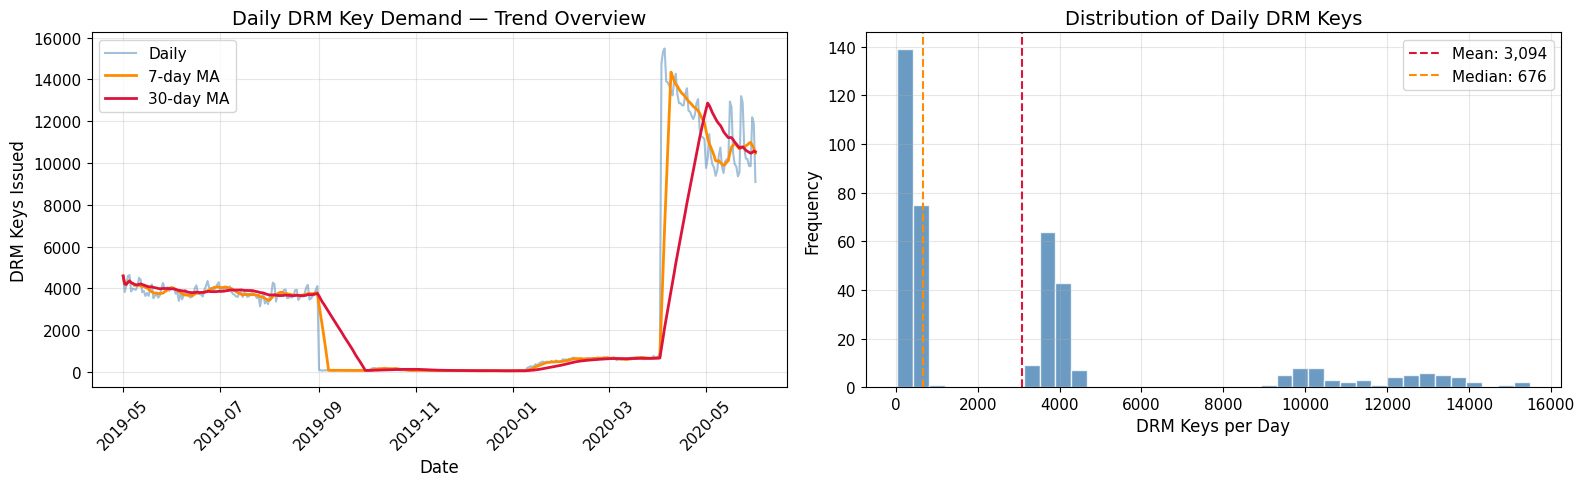

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time series plot
ax1 = axes[0]
ax1.plot(df['LogDate'], df['Total_Daily_Keys'], alpha=0.5, label='Daily', color='steelblue')
ax1.plot(df['LogDate'], df['MA_7'], label='7-day MA', color='darkorange', linewidth=2)
ax1.plot(df['LogDate'], df['MA_30'], label='30-day MA', color='crimson', linewidth=2)
ax1.set_title('Daily DRM Key Demand — Trend Overview')
ax1.set_xlabel('Date')
ax1.set_ylabel('DRM Keys Issued')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.tick_params(axis='x', rotation=45)

# Distribution
ax2 = axes[1]
ax2.hist(df['Total_Daily_Keys'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(df['Total_Daily_Keys'].mean(), color='crimson', linestyle='--', label=f'Mean: {df["Total_Daily_Keys"].mean():,.0f}')
ax2.axvline(df['Total_Daily_Keys'].median(), color='darkorange', linestyle='--', label=f'Median: {df["Total_Daily_Keys"].median():,.0f}')
ax2.set_title('Distribution of Daily DRM Keys')
ax2.set_xlabel('DRM Keys per Day')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.show()

In [4]:
stats = df['Total_Daily_Keys'].describe()
stats['IQR'] = stats['75%'] - stats['25%']
stats['CoV'] = df['Total_Daily_Keys'].std() / df['Total_Daily_Keys'].mean() * 100
print(stats.to_string())
print(f'\nCoefficient of Variation: {stats["CoV"]:.1f}%')

count      398.000000
mean      3094.092965
std       4019.767988
min         38.000000
25%         80.000000
50%        676.000000
75%       3942.250000
max      15478.000000
IQR       3862.250000
CoV        129.917492

Coefficient of Variation: 129.9%


In [5]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_stats = (
    df.groupby('DayOfWeekName')['Total_Daily_Keys']
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .reindex(day_order)
    .round(0)
)

display(weekday_stats)

,mean,median,std,min,max
DayOfWeekName,,,,,
Monday,3025.0,668.0,3972.0,46,13898
Tuesday,2893.0,638.0,3829.0,38,13847
Wednesday,2904.0,685.0,3784.0,43,13671
Thursday,2874.0,708.0,3715.0,44,13429
Friday,3116.0,665.0,3991.0,44,14770
Saturday,3427.0,694.0,4432.0,52,15326
Sunday,3416.0,693.0,4509.0,53,15478


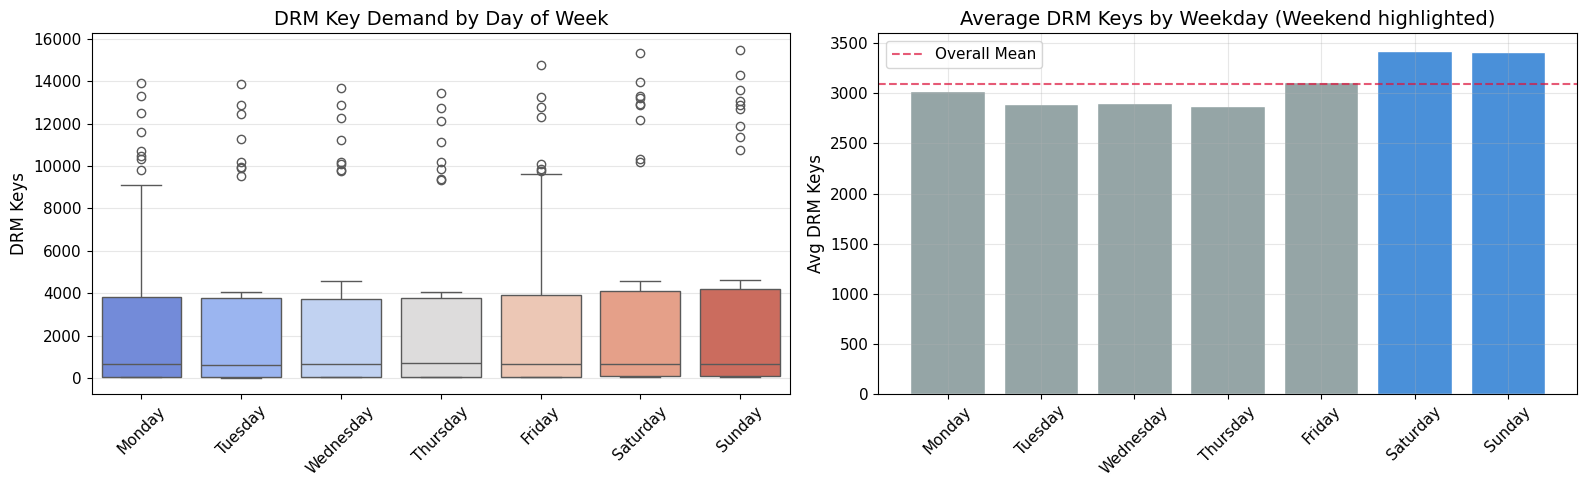

Weekend average: 3,422 | Weekday average: 2,963
Weekend uplift : +15.5%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot by day of week
ax1 = axes[0]
df_plot = df.copy()
df_plot['DayOfWeekName'] = pd.Categorical(df_plot['DayOfWeekName'], categories=day_order, ordered=True)
sns.boxplot(data=df_plot, x='DayOfWeekName', y='Total_Daily_Keys', ax=ax1, palette='coolwarm')
ax1.set_title('DRM Key Demand by Day of Week')
ax1.set_xlabel('')
ax1.set_ylabel('DRM Keys')
ax1.tick_params(axis='x', rotation=45)

# Mean bar chart with weekend highlight
ax2 = axes[1]
colors = ['#4a90d9' if d in ['Saturday', 'Sunday'] else '#95a5a6' for d in day_order]
ax2.bar(day_order, weekday_stats['mean'], color=colors, edgecolor='white')
ax2.axhline(df['Total_Daily_Keys'].mean(), color='crimson', linestyle='--', alpha=0.7, label='Overall Mean')
ax2.set_title('Average DRM Keys by Weekday (Weekend highlighted)')
ax2.set_ylabel('Avg DRM Keys')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

# Weekend vs weekday comparison
weekend_avg = df[df['IsWeekend'] == 1]['Total_Daily_Keys'].mean()
weekday_avg = df[df['IsWeekend'] == 0]['Total_Daily_Keys'].mean()
print(f'Weekend average: {weekend_avg:,.0f} | Weekday average: {weekday_avg:,.0f}')
print(f'Weekend uplift : {((weekend_avg / weekday_avg) - 1) * 100:+.1f}%')

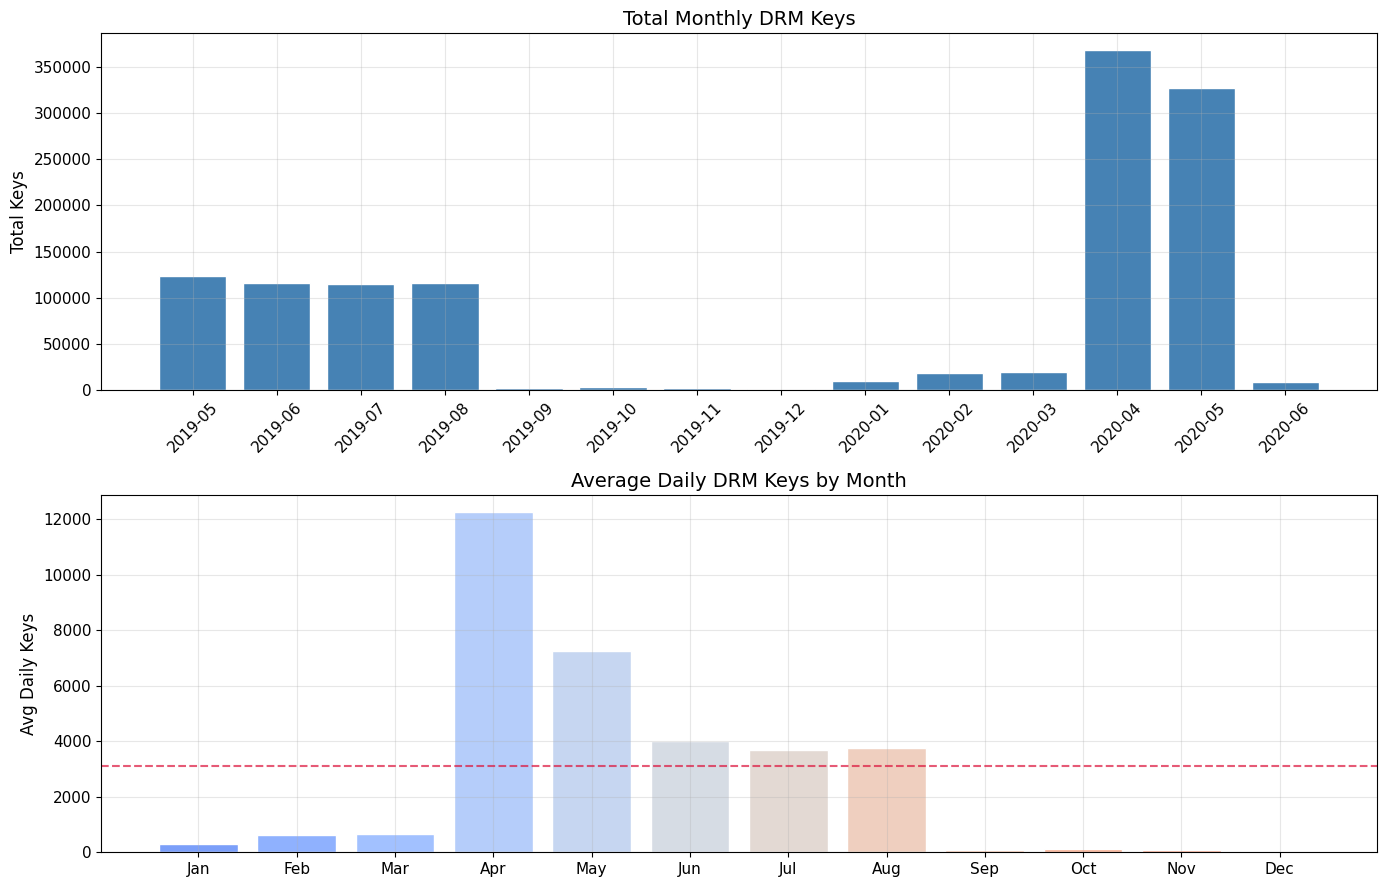

In [7]:
monthly_stats = (
    df.groupby(['Year', 'Month'])['Total_Daily_Keys']
    .agg(['sum', 'mean', 'max'])
    .reset_index()
)
monthly_stats['Period'] = monthly_stats['Year'].astype(str) + '-' + monthly_stats['Month'].astype(str).str.zfill(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Monthly total
ax1 = axes[0]
ax1.bar(monthly_stats['Period'], monthly_stats['sum'], color='steelblue', edgecolor='white')
ax1.set_title('Total Monthly DRM Keys')
ax1.set_ylabel('Total Keys')
ax1.tick_params(axis='x', rotation=45)

# Average daily by month (across years)
ax2 = axes[1]
month_avg = df.groupby('Month')['Total_Daily_Keys'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
colors_monthly = plt.cm.coolwarm(np.linspace(0.2, 0.8, 12))
ax2.bar(range(1, 13), month_avg.reindex(range(1, 13)).values, color=colors_monthly, edgecolor='white')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_names)
ax2.set_title('Average Daily DRM Keys by Month')
ax2.set_ylabel('Avg Daily Keys')
ax2.axhline(df['Total_Daily_Keys'].mean(), color='crimson', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

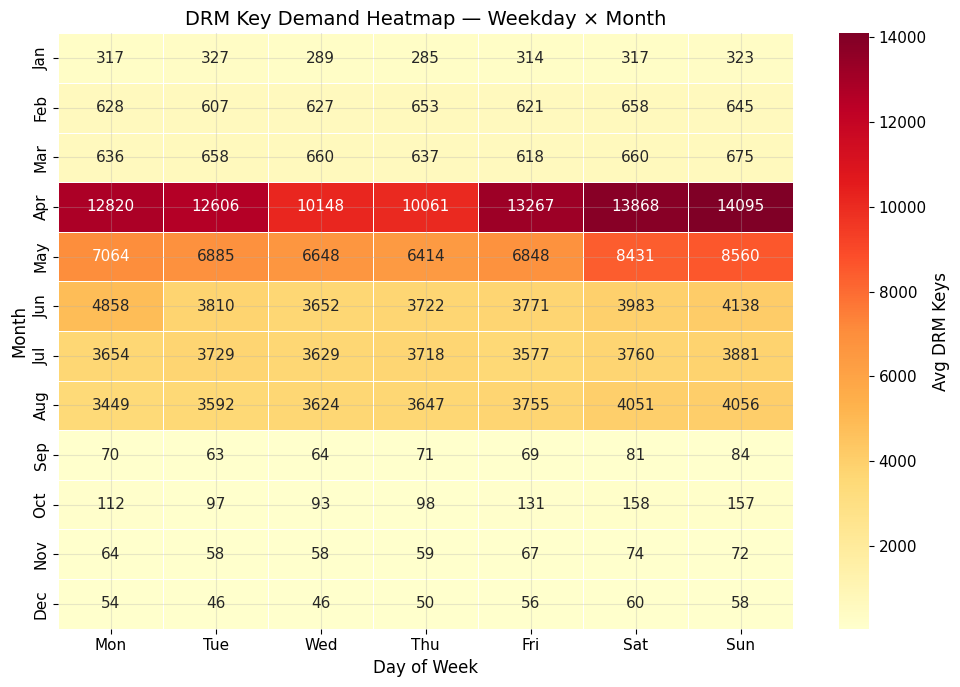

In [8]:
# Heatmap: weekday × month
heatmap_data = (
    df.groupby(['Month', 'DayOfWeek'])['Total_Daily_Keys']
    .mean()
    .unstack()
)
heatmap_data.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
heatmap_data.index = month_names[:len(heatmap_data)]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg DRM Keys'}
)
ax.set_title('DRM Key Demand Heatmap — Weekday × Month')
ax.set_ylabel('Month')
ax.set_xlabel('Day of Week')
plt.tight_layout()
plt.show()

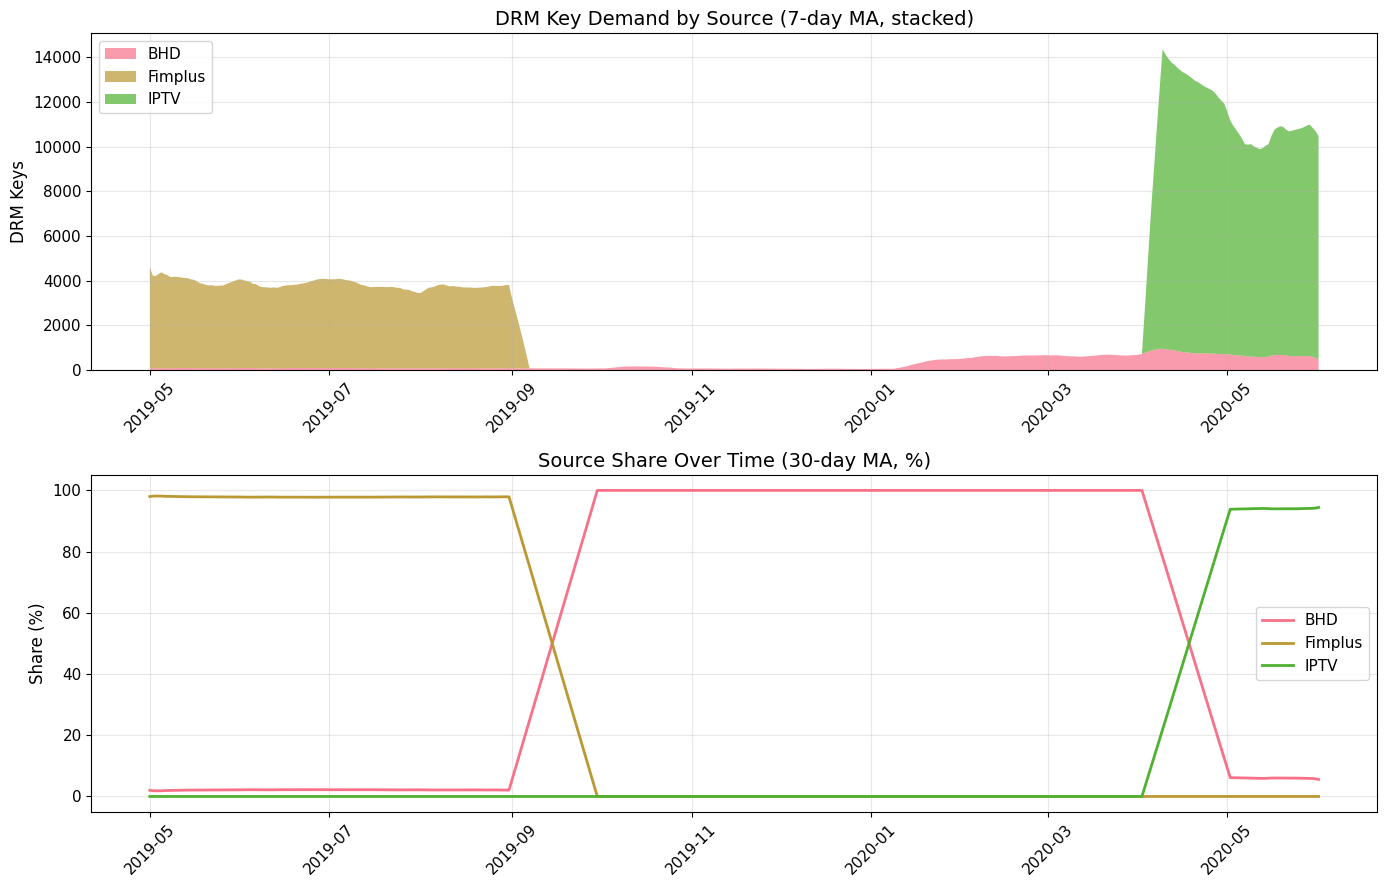

Overall source split:
         BHD:      110,879 (9.0%)
     Fimplus:      462,904 (37.5%)
        IPTV:      661,096 (53.5%)


In [9]:
source_cols = [c for c in df_source.columns if c != 'LogDate']

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Stacked area chart
ax1 = axes[0]
ax1.stackplot(
    df_source['LogDate'],
    *[df_source[col].rolling(7, min_periods=1).mean() for col in source_cols],
    labels=source_cols, alpha=0.7
)
ax1.set_title('DRM Key Demand by Source (7-day MA, stacked)')
ax1.set_ylabel('DRM Keys')
ax1.legend(loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.tick_params(axis='x', rotation=45)

# Proportion over time
ax2 = axes[1]
df_pct = df_source[source_cols].div(df_source[source_cols].sum(axis=1), axis=0)
df_pct_smooth = df_pct.rolling(30, min_periods=1).mean()
for col in source_cols:
    ax2.plot(df_source['LogDate'], df_pct_smooth[col] * 100, label=col, linewidth=2)
ax2.set_title('Source Share Over Time (30-day MA, %)')
ax2.set_ylabel('Share (%)')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Overall source split
total_by_source = df_source[source_cols].sum()
print('Overall source split:')
for src in source_cols:
    pct = total_by_source[src] / total_by_source.sum() * 100
    print(f'  {src:>10}: {total_by_source[src]:>12,.0f} ({pct:.1f}%)')

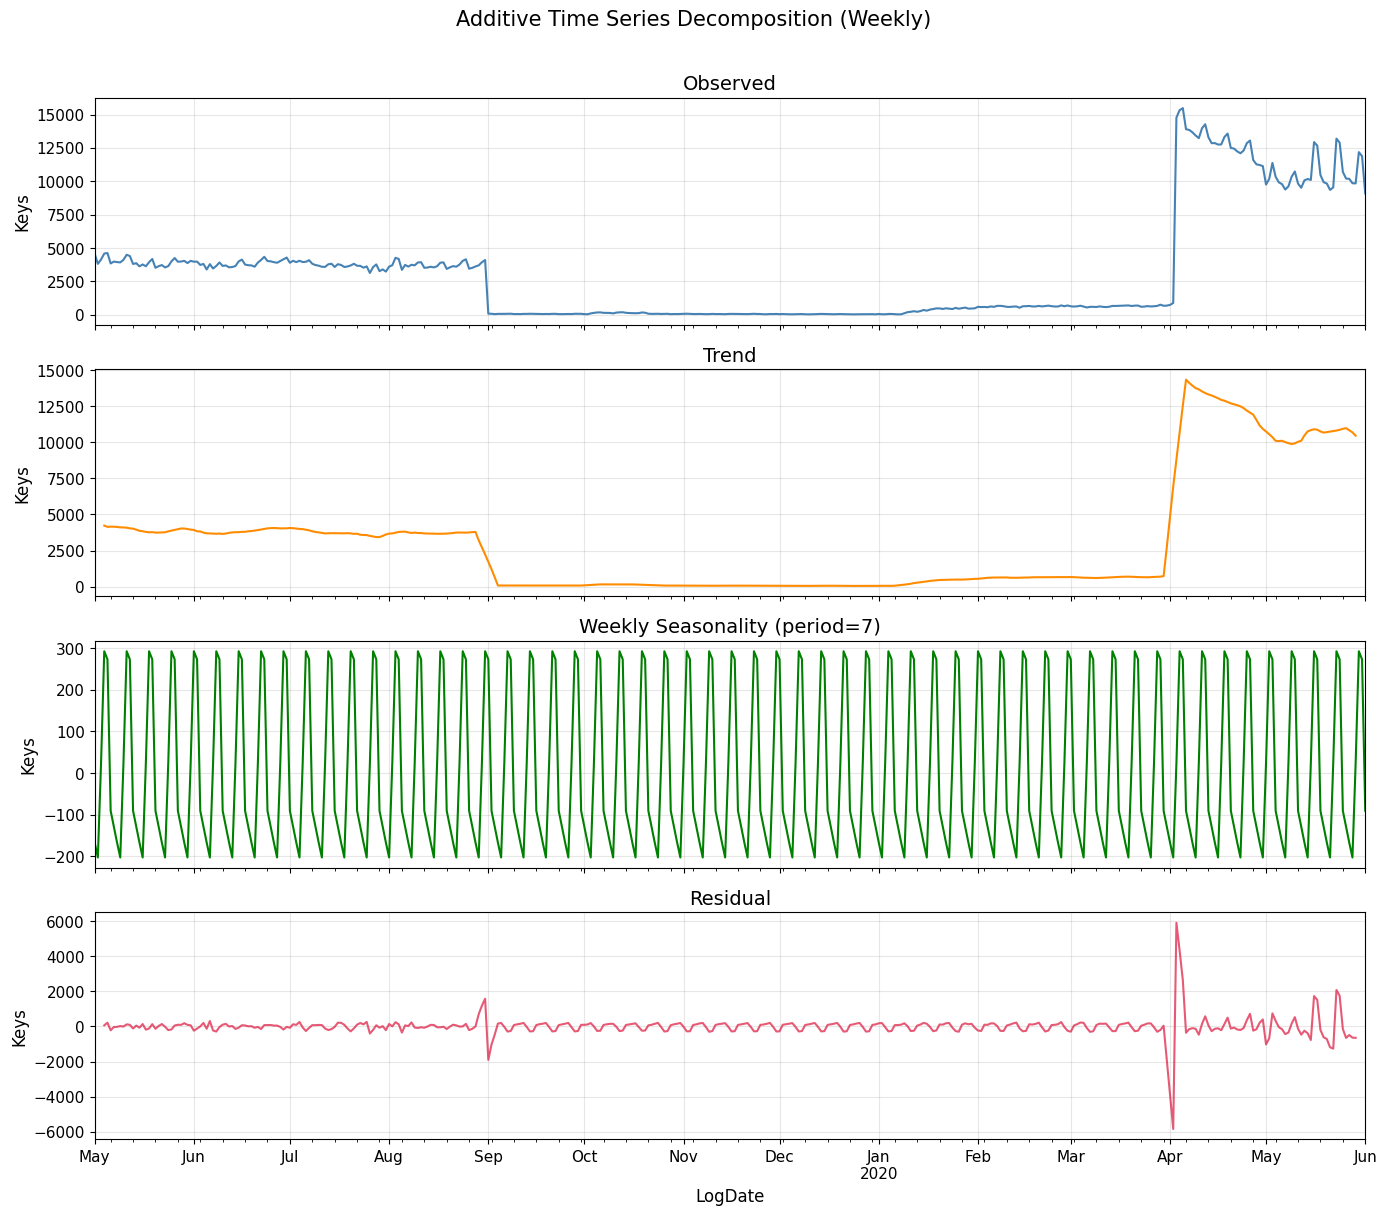

In [10]:
ts = df.set_index('LogDate')['Total_Daily_Keys']

# Weekly decomposition (period=7)
decomposition = seasonal_decompose(ts, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed')
axes[0].set_ylabel('Keys')

decomposition.trend.plot(ax=axes[1], color='darkorange')
axes[1].set_title('Trend')
axes[1].set_ylabel('Keys')

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Weekly Seasonality (period=7)')
axes[2].set_ylabel('Keys')

decomposition.resid.plot(ax=axes[3], color='crimson', alpha=0.7)
axes[3].set_title('Residual')
axes[3].set_ylabel('Keys')

plt.suptitle('Additive Time Series Decomposition (Weekly)', y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

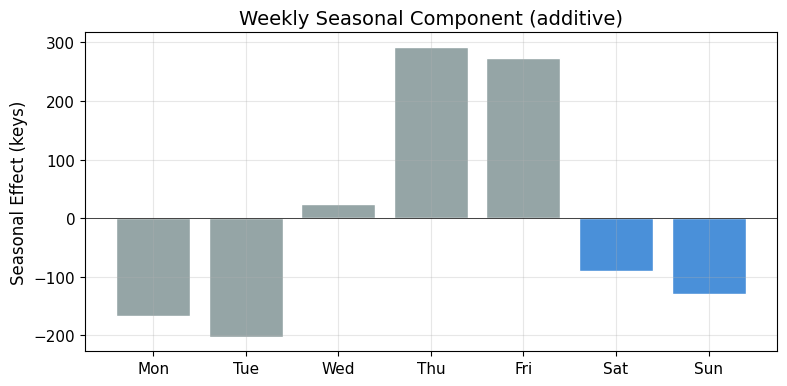

In [11]:
# Seasonal component — zoom into one representative week
seasonal_week = decomposition.seasonal[:7]

fig, ax = plt.subplots(figsize=(8, 4))
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors_bar = ['#4a90d9' if i >= 5 else '#95a5a6' for i in range(7)]
ax.bar(range(7), seasonal_week.values, color=colors_bar, edgecolor='white')
ax.set_xticks(range(7))
ax.set_xticklabels(day_labels)
ax.set_title('Weekly Seasonal Component (additive)')
ax.set_ylabel('Seasonal Effect (keys)')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()